In [2]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)
import xgboost as xgb

DB = Path("../data/processed/oral_oncology.db")
conn = sqlite3.connect(DB)

patients = pd.read_sql_query("SELECT * FROM patients", conn)
visits   = pd.read_sql_query("SELECT * FROM dental_visits", conn)
appts    = pd.read_sql_query("SELECT * FROM appointments", conn)
refs     = pd.read_sql_query("SELECT * FROM referrals", conn)

print(f"patients: {len(patients):,}  positives: {patients.oral_cancer_positive.sum()} ({patients.oral_cancer_positive.mean()*100:.1f}%)")

patients: 5,000  positives: 376 (7.5%)


In [3]:
# Aggregate visit-level info per patient
visit_agg = visits.groupby("patient_id").agg(
    n_visits=("visit_id", "count"),
    n_lesion_visits=("lesion_present", "sum"),
    any_lesion_ever=("lesion_present", "max"),
    screening_rate=("screening_completed", "mean"),
).reset_index()

# Aggregate appointment-level info per patient
appt_agg = appts.groupby("patient_id").agg(
    n_appts=("appointment_id", "count"),
    no_show_rate=("no_show_flag", "mean"),
).reset_index()

# Aggregate referral counts
ref_agg = refs.groupby("patient_id").agg(
    n_referrals=("referral_id", "count"),
).reset_index()

# Join everything onto patients
df = (patients
      .merge(visit_agg, on="patient_id", how="left")
      .merge(appt_agg,  on="patient_id", how="left")
      .merge(ref_agg,   on="patient_id", how="left"))

# Patients with no referrals get 0
df[["n_referrals"]] = df[["n_referrals"]].fillna(0)

print(df.shape)
df.head()

(5000, 18)


,patient_id,age,sex,race_ethnicity,insurance_type,zip_code,smoking_status,alcohol_use,hpv_status,socioeconomic_risk_score,oral_cancer_positive,n_visits,n_lesion_visits,any_lesion_ever,screening_rate,n_appts,no_show_rate,n_referrals
0,P00001,76,F,Hispanic,Medicaid,15236,Former,Light,Negative,0.348,0,6,0,0,0.666667,4,0.0,0.0
1,P00002,66,F,White,Private,15238,Current,Heavy,Negative,0.168,0,4,0,0,1.000000,3,0.0,0.0
2,P00003,61,F,White,Medicaid,15232,Never,No use,Negative,0.222,0,4,1,1,0.750000,7,0.0,0.0
3,P00004,66,M,Hispanic,Medicare,15235,Never,No use,Negative,0.527,0,6,1,1,0.333333,3,0.0,0.0
4,P00005,72,M,White,Medicaid,15235,Former,Light,Negative,0.484,0,4,2,1,0.750000,2,0.0,0.0


In [4]:
# Categorical columns -> one-hot encoded
cat_cols = ["sex", "race_ethnicity", "insurance_type", "smoking_status",
            "alcohol_use", "hpv_status"]
num_cols = ["age", "socioeconomic_risk_score", "n_visits", "n_lesion_visits",
            "any_lesion_ever", "screening_rate", "n_appts", "no_show_rate",
            "n_referrals"]

X = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols, drop_first=True)
y = df["oral_cancer_positive"]

print(f"Feature matrix: {X.shape}")
print(f"Class balance: {y.value_counts().to_dict()}")
X.columns.tolist()

Feature matrix: (5000, 24)
Class balance: {0: 4624, 1: 376}


['age',
 'socioeconomic_risk_score',
 'n_visits',
 'n_lesion_visits',
 'any_lesion_ever',
 'screening_rate',
 'n_appts',
 'no_show_rate',
 'n_referrals',
 'sex_M',
 'race_ethnicity_Black',
 'race_ethnicity_Hispanic',
 'race_ethnicity_Other',
 'race_ethnicity_White',
 'insurance_type_Medicare',
 'insurance_type_Private',
 'insurance_type_Uninsured',
 'smoking_status_Former',
 'smoking_status_Never',
 'alcohol_use_Light',
 'alcohol_use_Moderate',
 'alcohol_use_No use',
 'hpv_status_Positive',
 'hpv_status_Unknown']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Train: {len(X_train):,}  positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test:  {len(X_test):,}  positives: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Train: 4,000  positives: 301 (7.5%)
Test:  1,000  positives: 75 (7.5%)


In [6]:
# Scale features for logistic regression (tree models don't need it)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

models = {}

# 1) Logistic Regression baseline
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_scaled, y_train)
models["Logistic Regression"] = (lr, X_test_scaled)

# 2) Random Forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
models["Random Forest"] = (rf, X_test.values)

# 3) XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    scale_pos_weight=neg/pos,
    eval_metric="logloss", random_state=42, n_jobs=-1
)
xgb_clf.fit(X_train, y_train)
models["XGBoost"] = (xgb_clf, X_test.values)

print("Trained:", list(models.keys()))

Trained: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [7]:
def evaluate(name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    return {
        "model": name,
        "accuracy": (y_pred == y_true).mean(),
        "recall (cancer)": (y_pred[y_true == 1] == 1).mean(),
        "precision (cancer)": ((y_pred == 1) & (y_true == 1)).sum() / max(1, (y_pred == 1).sum()),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
    }

results = pd.DataFrame([evaluate(name, m, X_eval, y_test) for name, (m, X_eval) in models.items()])
results = results.set_index("model").round(3)
results

/opt/anaconda3/envs/oral-onc/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/oral-onc/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,accuracy,recall (cancer),precision (cancer),ROC-AUC,PR-AUC
model,,,,,
Logistic Regression,0.747,0.720,0.189,0.826,0.367
Random Forest,0.913,0.267,0.385,0.780,0.289
XGBoost,0.881,0.253,0.232,0.754,0.253


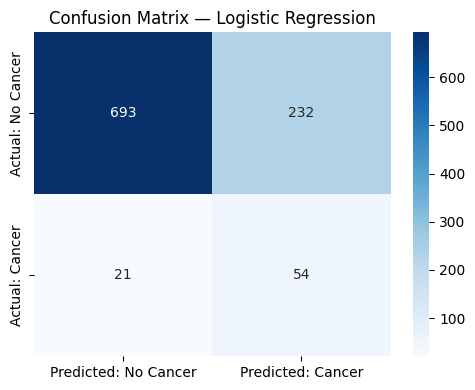

              precision    recall  f1-score   support

   No Cancer       0.97      0.75      0.85       925
      Cancer       0.19      0.72      0.30        75

    accuracy                           0.75      1000
   macro avg       0.58      0.73      0.57      1000
weighted avg       0.91      0.75      0.80      1000



In [8]:
# Pick the model with highest PR-AUC (best balance for imbalanced classes)
best_name = results["PR-AUC"].idxmax()
best_model, X_eval = models[best_name]
y_pred = best_model.predict(X_eval)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: No Cancer", "Predicted: Cancer"],
            yticklabels=["Actual: No Cancer", "Actual: Cancer"], ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["No Cancer", "Cancer"]))

/opt/anaconda3/envs/oral-onc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


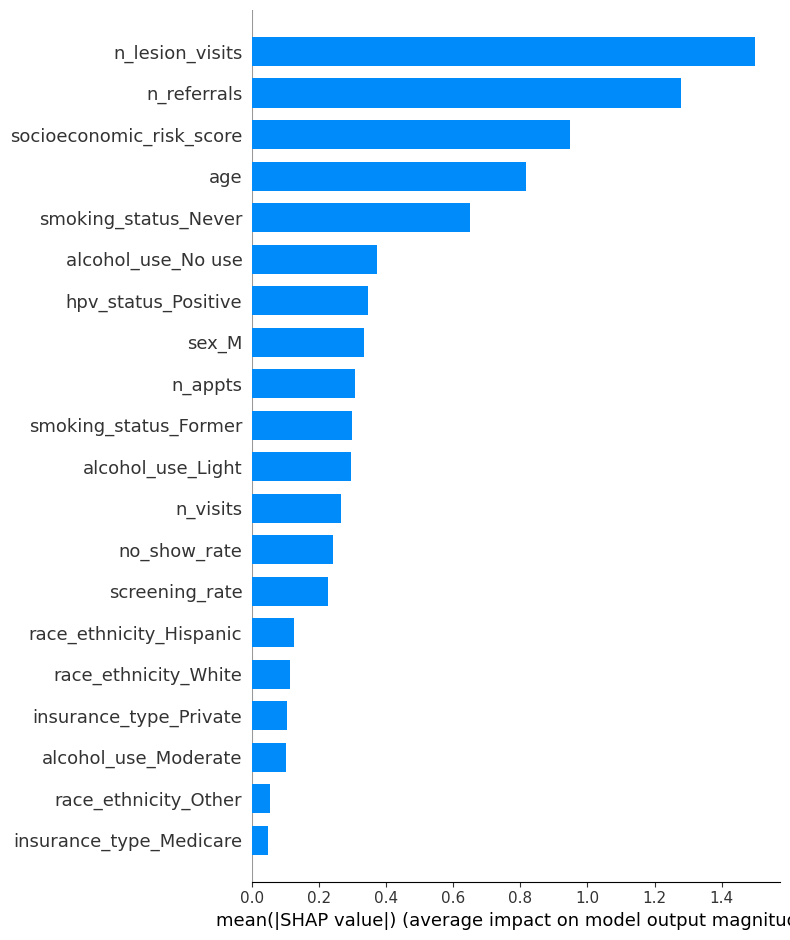

In [9]:
import shap

# SHAP works best with tree models, use the XGBoost model
xgb_model = models["XGBoost"][0]
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Global feature importance plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

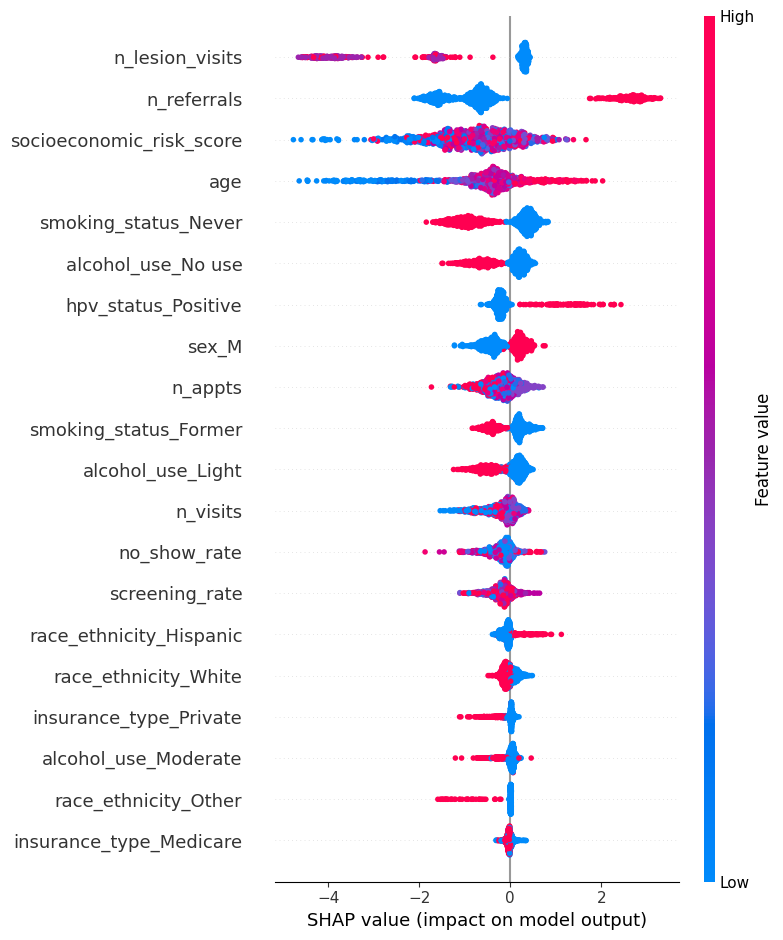

In [10]:
# The "beeswarm" — shows how each feature pushes predictions higher or lower
shap.summary_plot(shap_values, X_test, show=True)